In [1]:
import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import statsmodels.api as sm

/Users/mariairenetenerani/anaconda3/envs/Apple_tensorflow_env/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


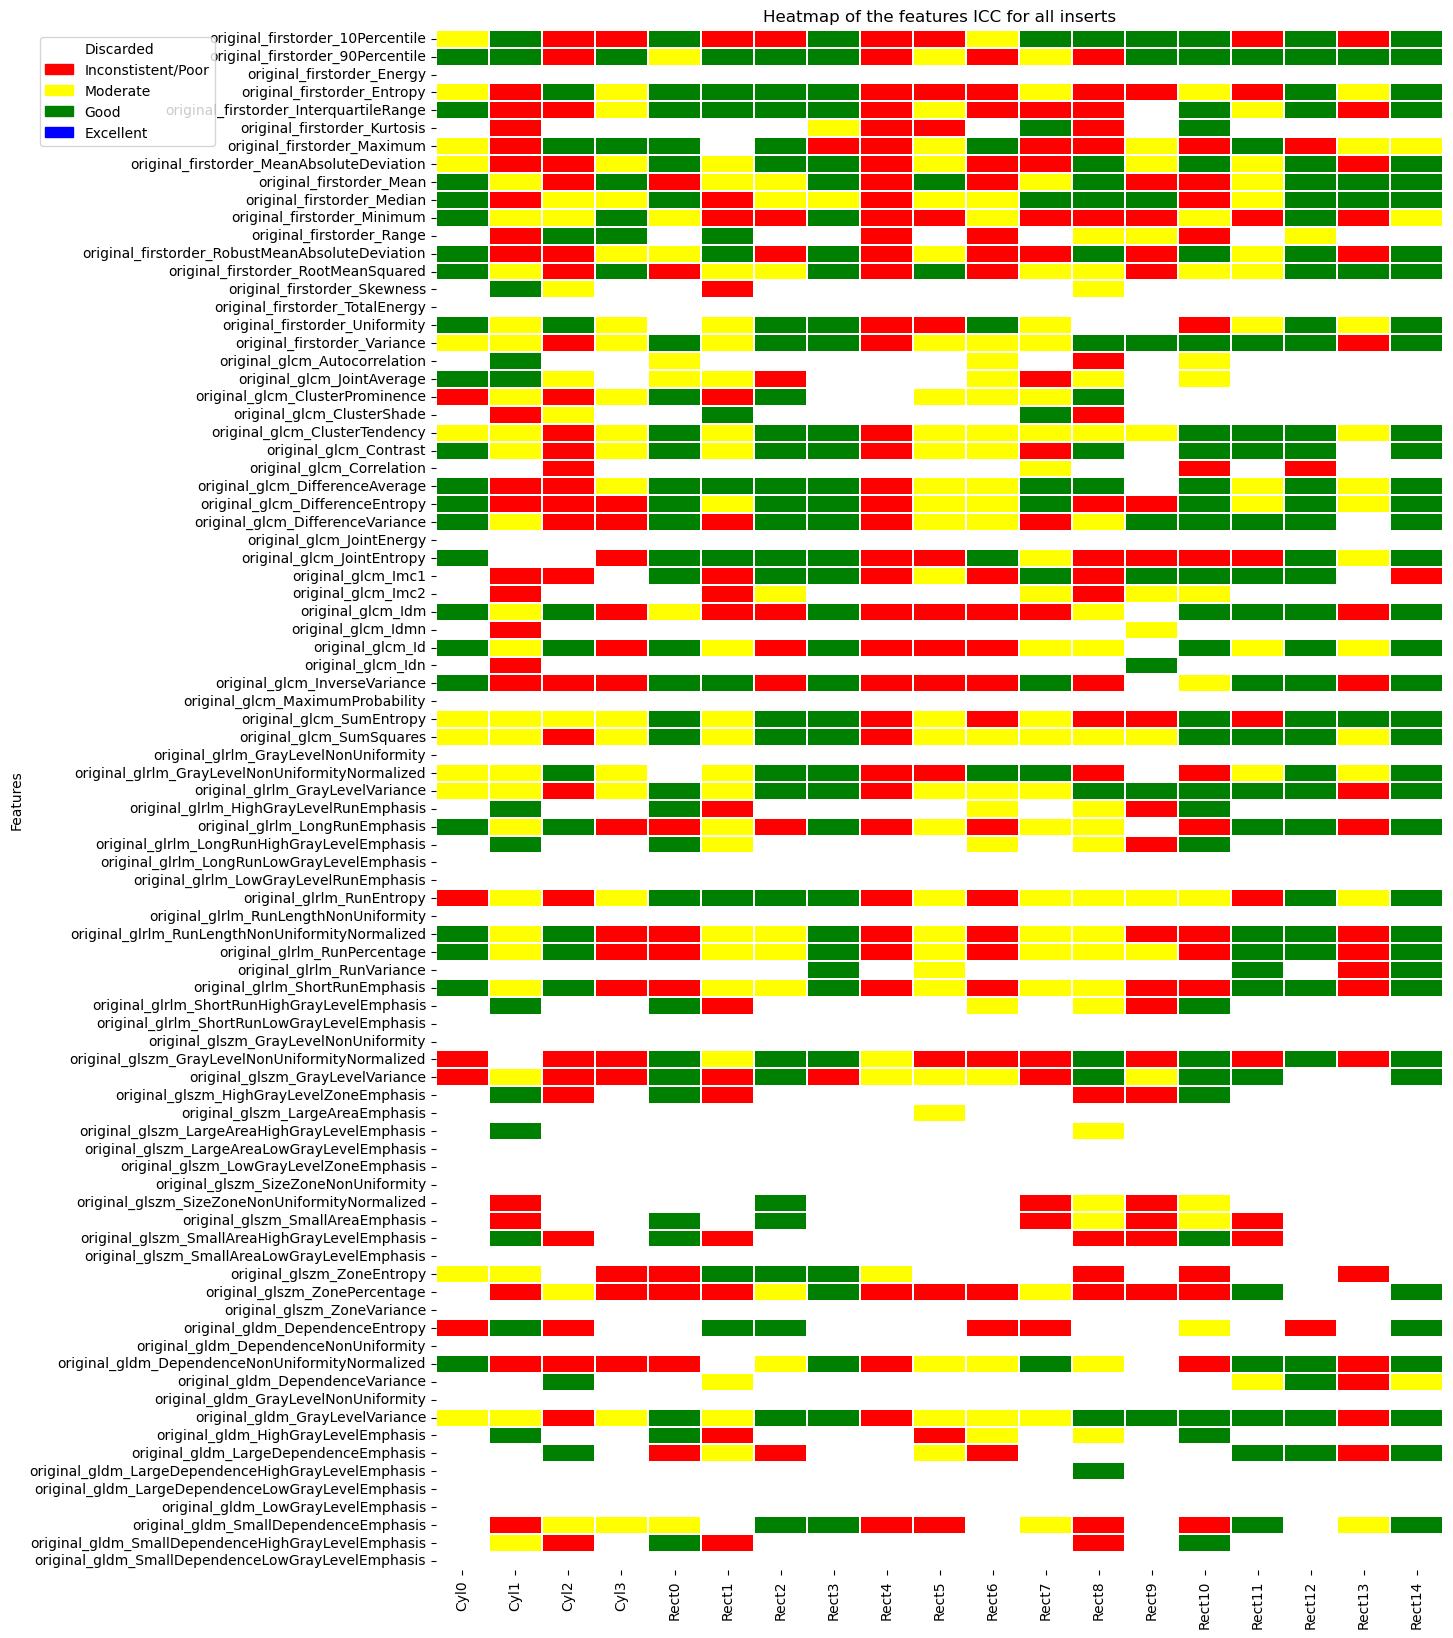

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect0,Rect1,Rect2,Rect3,Rect4,Rect5,Rect6,Rect7,Rect8,Rect9,Rect10,Rect11,Rect12,Rect13,Rect14
0,original_firstorder_10Percentile,2,3,1,1,3,1,1,4,1,1,2,3,3,3,4,1,3,1,4
1,original_firstorder_90Percentile,3,3,1,3,2,3,3,3,1,2,1,2,1,3,3,3,3,3,4
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,3,4,4,1,1,1,2,1,1,2,1,4,2,4
4,original_firstorder_InterquartileRange,3,1,1,2,3,3,4,3,1,2,1,1,1,0,3,2,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,2,0,3,4,1,1,0,2,1,0,1,3,0,2,3
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,3,1,0,0,0,0,0,0,1,0,3,0,0,0,0


In [ ]:

import matplotlib.patches as mpatches
#Repeat everything for Cyl1
#Load csv file into dataframe
df = pd.read_csv('../../../RadiomiK/Features_Global/cyl1_glob.csv')

features_names_all = df.columns[0:86]

#create a dataframe with the features names
df_heat = pd.DataFrame(features_names_all)

df_heat.columns = ['Features']

# add the void columns Test-retest, Cyl1_Pos and Cyl1_Vol
df_heat['Cyl0'] = 0
df_heat['Cyl1'] = 0
df_heat['Cyl2'] = 0
df_heat['Cyl3'] = 0
df_heat['Rect0'] = 0
df_heat['Rect1'] = 0
df_heat['Rect2'] = 0
df_heat['Rect3'] = 0
df_heat['Rect4'] = 0
df_heat['Rect5'] = 0
df_heat['Rect6'] = 0
df_heat['Rect7'] = 0
df_heat['Rect8'] = 0
df_heat['Rect9'] = 0
df_heat['Rect10'] = 0
df_heat['Rect11'] = 0
df_heat['Rect12'] = 0
df_heat['Rect13'] = 0
df_heat['Rect14'] = 0

#Load the csv file the ICC values
ICC_Cyl0 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Cyl0_glob.csv')
ICC_Cyl1 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Cyl1_glob.csv')
ICC_Cyl2 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Cyl2_glob.csv')
ICC_Cyl3 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Cyl3_glob.csv')
ICC_Rect0 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect0_glob.csv')
ICC_Rect1 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect1_glob.csv')
ICC_Rect2 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect2_glob.csv')
ICC_Rect3 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect3_glob.csv')
ICC_Rect4 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect4_glob.csv')
ICC_Rect5 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect5_glob.csv')
ICC_Rect6 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect6_glob.csv')
ICC_Rect7 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect7_glob.csv')
ICC_Rect8 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect8_glob.csv')
ICC_Rect9 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect9_glob.csv')
ICC_Rect10 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect10_glob.csv') 
ICC_Rect11 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect11_glob.csv')
ICC_Rect12 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect12_glob.csv')
ICC_Rect13 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect13_glob.csv')
ICC_Rect14 = pd.read_csv('../../../../RadiomiK/ICC_values/ICC_Rect14_glob.csv')


# Itera su tutte le righe in df_heat
for index, row in df_heat.iterrows():
    if row['Features'] in ICC_Cyl0[ICC_Cyl0['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Cyl0'] = 1
    if row['Features'] in ICC_Cyl0[ICC_Cyl0['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Cyl0'] = 1
    if row['Features'] in ICC_Cyl0[ICC_Cyl0['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Cyl0'] = 2 
    if row['Features'] in ICC_Cyl0[ICC_Cyl0['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Cyl0'] = 3
    if row['Features'] in ICC_Cyl0[ICC_Cyl0['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Cyl0'] = 4       
    if row['Features'] in ICC_Cyl1[ICC_Cyl1['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Cyl1'] = 1
    if row['Features'] in ICC_Cyl1[ICC_Cyl1['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Cyl1'] = 1
    if row['Features'] in ICC_Cyl1[ICC_Cyl1['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Cyl1'] = 2
    if row['Features'] in ICC_Cyl1[ICC_Cyl1['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Cyl1'] = 3
    if row['Features'] in ICC_Cyl1[ICC_Cyl1['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Cyl1'] = 4
    if row['Features'] in ICC_Cyl2[ICC_Cyl2['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Cyl2'] = 1
    if row['Features'] in ICC_Cyl2[ICC_Cyl2['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Cyl2'] = 1
    if row['Features'] in ICC_Cyl2[ICC_Cyl2['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Cyl2'] = 2
    if row['Features'] in ICC_Cyl2[ICC_Cyl2['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Cyl2'] = 3
    if row['Features'] in ICC_Cyl2[ICC_Cyl2['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Cyl2'] = 4
    if row['Features'] in ICC_Cyl3[ICC_Cyl3['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Cyl3'] = 1
    if row['Features'] in ICC_Cyl3[ICC_Cyl3['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Cyl3'] = 1
    if row['Features'] in ICC_Cyl3[ICC_Cyl3['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Cyl3'] = 2
    if row['Features'] in ICC_Cyl3[ICC_Cyl3['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Cyl3'] = 3
    if row['Features'] in ICC_Cyl3[ICC_Cyl3['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Cyl3'] = 4
    if row['Features'] in ICC_Rect0[ICC_Rect0['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect0'] = 1
    if row['Features'] in ICC_Rect0[ICC_Rect0['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect0'] = 1
    if row['Features'] in ICC_Rect0[ICC_Rect0['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect0'] = 2
    if row['Features'] in ICC_Rect0[ICC_Rect0['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect0'] = 3
    if row['Features'] in ICC_Rect0[ICC_Rect0['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect0'] = 4
    if row['Features'] in ICC_Rect1[ICC_Rect1['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect1'] = 1
    if row['Features'] in ICC_Rect1[ICC_Rect1['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect1'] = 1
    if row['Features'] in ICC_Rect1[ICC_Rect1['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect1'] = 2
    if row['Features'] in ICC_Rect1[ICC_Rect1['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect1'] = 3
    if row['Features'] in ICC_Rect1[ICC_Rect1['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect1'] = 4
    if row['Features'] in ICC_Rect2[ICC_Rect2['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect2'] = 1
    if row['Features'] in ICC_Rect2[ICC_Rect2['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect2'] = 1
    if row['Features'] in ICC_Rect2[ICC_Rect2['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect2'] = 2
    if row['Features'] in ICC_Rect2[ICC_Rect2['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect2'] = 3
    if row['Features'] in ICC_Rect2[ICC_Rect2['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect2'] = 4
    if row['Features'] in ICC_Rect3[ICC_Rect3['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect3'] = 1
    if row['Features'] in ICC_Rect3[ICC_Rect3['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect3'] = 1
    if row['Features'] in ICC_Rect3[ICC_Rect3['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect3'] = 2
    if row['Features'] in ICC_Rect3[ICC_Rect3['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect3'] = 3
    if row['Features'] in ICC_Rect3[ICC_Rect3['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect3'] = 4
    if row['Features'] in ICC_Rect4[ICC_Rect4['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect4'] = 1
    if row['Features'] in ICC_Rect4[ICC_Rect4['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect4'] = 1
    if row['Features'] in ICC_Rect4[ICC_Rect4['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect4'] = 2
    if row['Features'] in ICC_Rect4[ICC_Rect4['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect4'] = 3
    if row['Features'] in ICC_Rect4[ICC_Rect4['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect4'] = 4
    if row['Features'] in ICC_Rect5[ICC_Rect5['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect5'] = 1
    if row['Features'] in ICC_Rect5[ICC_Rect5['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect5'] = 1
    if row['Features'] in ICC_Rect5[ICC_Rect5['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect5'] = 2
    if row['Features'] in ICC_Rect5[ICC_Rect5['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect5'] = 3
    if row['Features'] in ICC_Rect5[ICC_Rect5['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect5'] = 4
    if row['Features'] in ICC_Rect6[ICC_Rect6['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect6'] = 1
    if row['Features'] in ICC_Rect6[ICC_Rect6['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect6'] = 1
    if row['Features'] in ICC_Rect6[ICC_Rect6['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect6'] = 2
    if row['Features'] in ICC_Rect6[ICC_Rect6['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect6'] = 3
    if row['Features'] in ICC_Rect6[ICC_Rect6['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect6'] = 4
    if row['Features'] in ICC_Rect7[ICC_Rect7['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect7'] = 1
    if row['Features'] in ICC_Rect7[ICC_Rect7['R'] == 'Poor']['name'].values:   
        df_heat.loc[index, 'Rect7'] = 1
    if row['Features'] in ICC_Rect7[ICC_Rect7['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect7'] = 2
    if row['Features'] in ICC_Rect7[ICC_Rect7['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect7'] = 3
    if row['Features'] in ICC_Rect7[ICC_Rect7['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect7'] = 4
    if row['Features'] in ICC_Rect8[ICC_Rect8['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect8'] = 1
    if row['Features'] in ICC_Rect8[ICC_Rect8['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect8'] = 1
    if row['Features'] in ICC_Rect8[ICC_Rect8['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect8'] = 2
    if row['Features'] in ICC_Rect8[ICC_Rect8['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect8'] = 3
    if row['Features'] in ICC_Rect8[ICC_Rect8['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect8'] = 4
    if row['Features'] in ICC_Rect9[ICC_Rect9['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect9'] = 1
    if row['Features'] in ICC_Rect9[ICC_Rect9['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect9'] = 1
    if row['Features'] in ICC_Rect9[ICC_Rect9['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect9'] = 2
    if row['Features'] in ICC_Rect9[ICC_Rect9['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect9'] = 3
    if row['Features'] in ICC_Rect9[ICC_Rect9['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect9'] = 4
    if row['Features'] in ICC_Rect10[ICC_Rect10['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect10'] = 1
    if row['Features'] in ICC_Rect10[ICC_Rect10['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect10'] = 1
    if row['Features'] in ICC_Rect10[ICC_Rect10['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect10'] = 2    
    if row['Features'] in ICC_Rect10[ICC_Rect10['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect10'] = 3
    if row['Features'] in ICC_Rect10[ICC_Rect10['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect10'] = 4
    if row['Features'] in ICC_Rect11[ICC_Rect11['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect11'] = 1
    if row['Features'] in ICC_Rect11[ICC_Rect11['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect11'] = 1
    if row['Features'] in ICC_Rect11[ICC_Rect11['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect11'] = 2
    if row['Features'] in ICC_Rect11[ICC_Rect11['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect11'] = 3
    if row['Features'] in ICC_Rect11[ICC_Rect11['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect11'] = 4
    if row['Features'] in ICC_Rect12[ICC_Rect12['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect12'] = 1
    if row['Features'] in ICC_Rect12[ICC_Rect12['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect12'] = 1
    if row['Features'] in ICC_Rect12[ICC_Rect12['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect12'] = 2
    if row['Features'] in ICC_Rect12[ICC_Rect12['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect12'] = 3
    if row['Features'] in ICC_Rect12[ICC_Rect12['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect12'] = 4
    if row['Features'] in ICC_Rect13[ICC_Rect13['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect13'] = 1
    if row['Features'] in ICC_Rect13[ICC_Rect13['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect13'] = 1
    if row['Features'] in ICC_Rect13[ICC_Rect13['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect13'] = 2
    if row['Features'] in ICC_Rect13[ICC_Rect13['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect13'] = 3
    if row['Features'] in ICC_Rect13[ICC_Rect13['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect13'] = 4
    if row['Features'] in ICC_Rect14[ICC_Rect14['R'] == 'Inconsistent']['name'].values:
        df_heat.loc[index, 'Rect14'] = 1
    if row['Features'] in ICC_Rect14[ICC_Rect14['R'] == 'Poor']['name'].values:
        df_heat.loc[index, 'Rect14'] = 1
    if row['Features'] in ICC_Rect14[ICC_Rect14['R'] == 'Moderate']['name'].values:
        df_heat.loc[index, 'Rect14'] = 2
    if row['Features'] in ICC_Rect14[ICC_Rect14['R'] == 'Good']['name'].values:
        df_heat.loc[index, 'Rect14'] = 3
    if row['Features'] in ICC_Rect14[ICC_Rect14['R'] == 'Excellent']['name'].values:
        df_heat.loc[index, 'Rect14'] = 4
        
#Elimina le righe che hanno in 'features' la stringa 'ngtdm'
df_heat = df_heat[~df_heat['Features'].str.contains('ngtdm')]   

# Imposta 'Features' come indice del DataFrame
df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_index
# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "yellow", "green", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(13, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)

# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor')
yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good')
blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, yellow_patch, green_patch, blue_patch], bbox_to_anchor=(-0.4, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC for all inserts')


# Mostra il grafico
plt.show()

df_heat

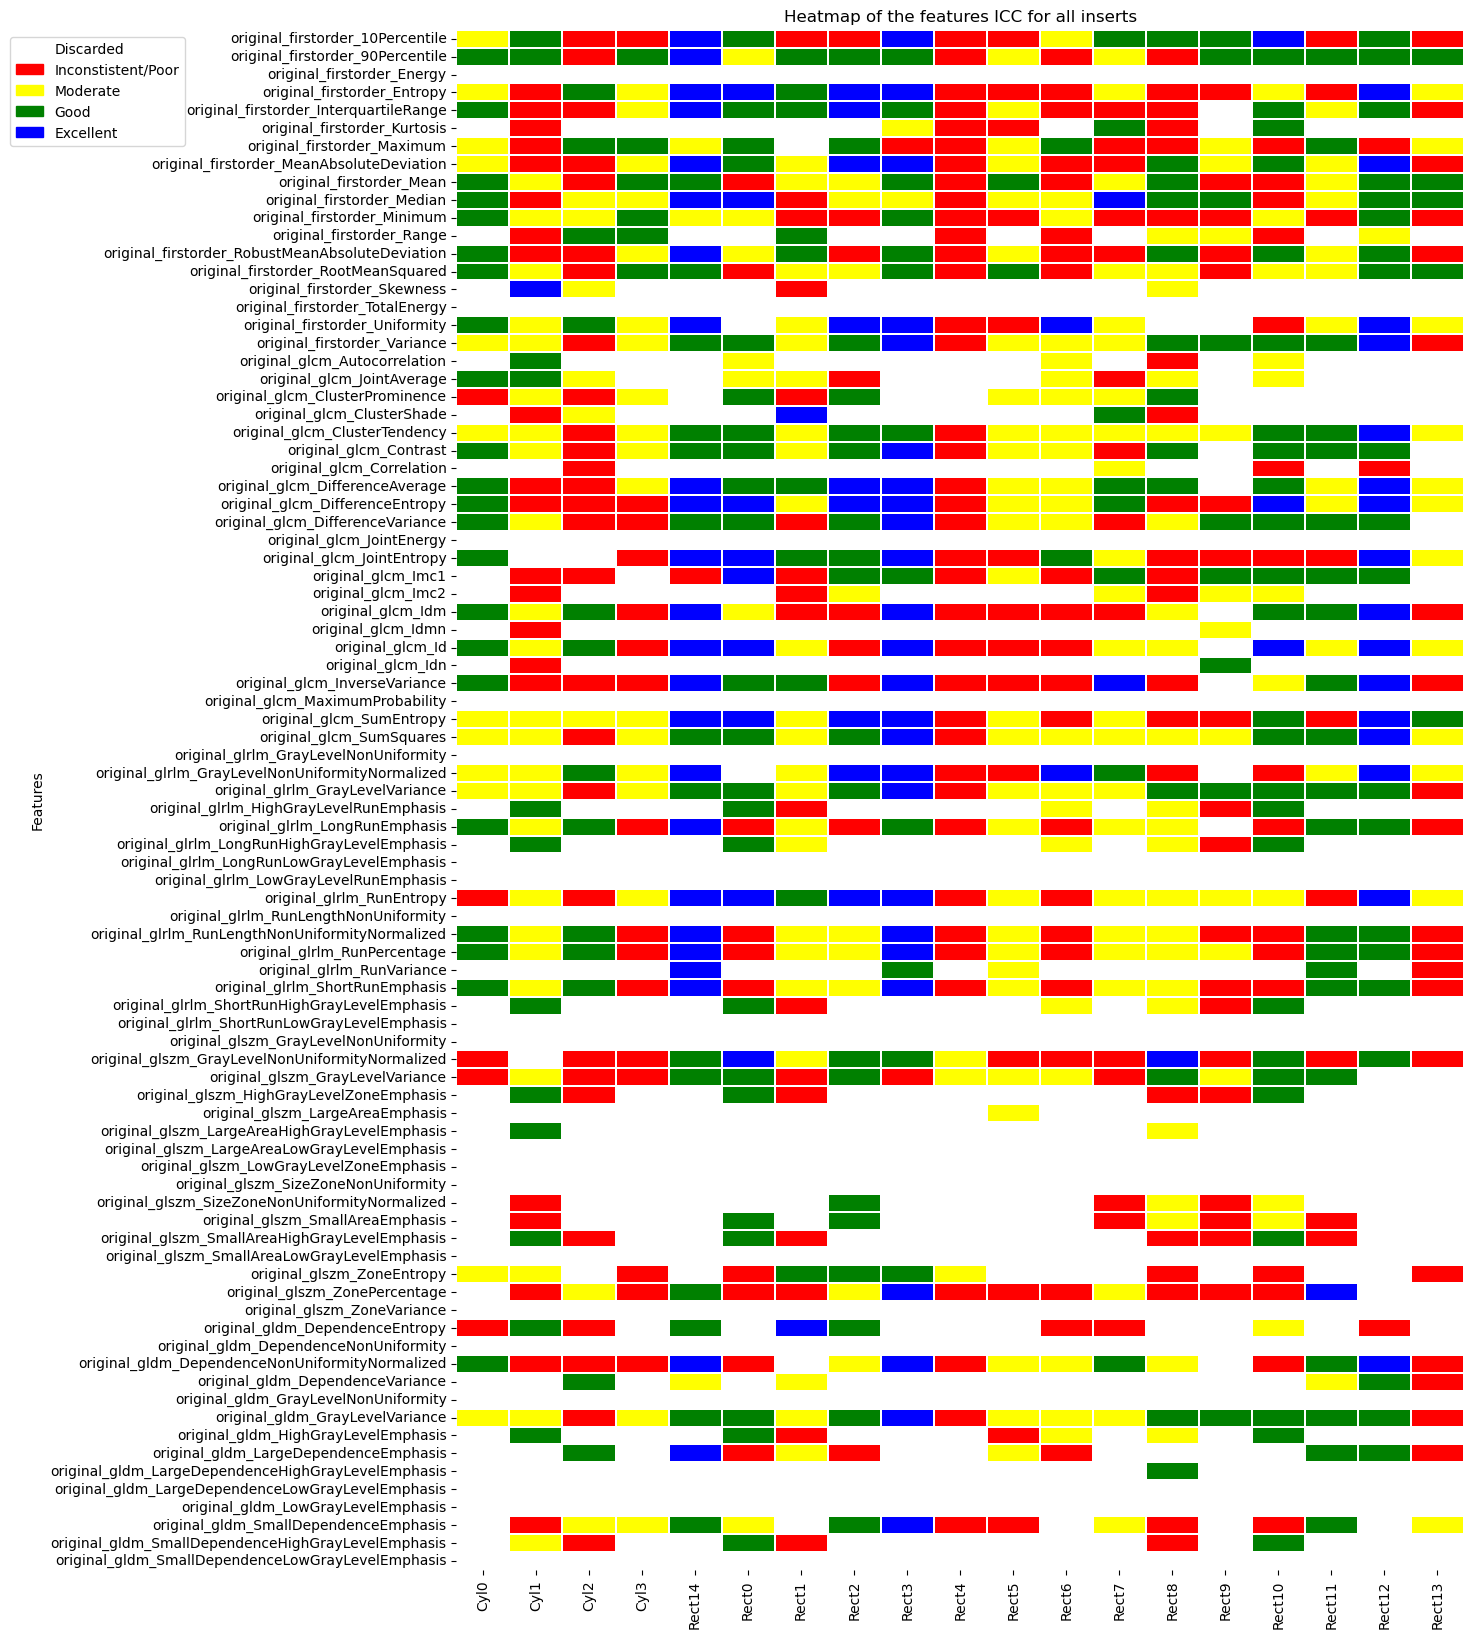

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect14,Rect0,Rect1,Rect2,Rect3,Rect4,Rect5,Rect6,Rect7,Rect8,Rect9,Rect10,Rect11,Rect12,Rect13
0,original_firstorder_10Percentile,2,3,1,1,4,3,1,1,4,1,1,2,3,3,3,4,1,3,1
1,original_firstorder_90Percentile,3,3,1,3,4,2,3,3,3,1,2,1,2,1,3,3,3,3,3
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,4,3,4,4,1,1,1,2,1,1,2,1,4,2
4,original_firstorder_InterquartileRange,3,1,1,2,4,3,3,4,3,1,2,1,1,1,0,3,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,3,2,0,3,4,1,1,0,2,1,0,1,3,0,2
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,0,3,1,0,0,0,0,0,0,1,0,3,0,0,0


In [3]:
#Change the order of the columns
df_heat = df_heat[['Features', 'Cyl0', 'Cyl1', 'Cyl2', 'Cyl3', 'Rect14', 'Rect0', 'Rect1', 'Rect2', 'Rect3', 'Rect4',  'Rect5',  'Rect6',  'Rect7', 'Rect8',  'Rect9',  'Rect10',  'Rect11',  'Rect12',  'Rect13']]

# Imposta 'Features' come indice del DataFrame
df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_index
# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "yellow", "green", "blue"])

# Imposta le dimensioni della figura
plt.figure(figsize=(13, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)

# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor')
yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good')
blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, yellow_patch, green_patch, blue_patch], bbox_to_anchor=(-0.45, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC for all inserts')


# Mostra il grafico
plt.show()

df_heat


Cyl0 22 39 0.5641025641025641
Cyl1 13 58 0.22413793103448276
Cyl2 13 49 0.2653061224489796
Cyl3 6 40 0.15
Rect14 38 42 0.9047619047619048
Rect0 32 49 0.6530612244897959
Rect1 12 52 0.23076923076923078
Rect2 28 46 0.6086956521739131
Rect3 37 41 0.9024390243902439
Rect4 0 41 0.0
Rect5 2 44 0.045454545454545456
Rect6 4 47 0.0851063829787234
Rect7 10 47 0.2127659574468085
Rect8 14 57 0.24561403508771928
Rect9 9 38 0.23684210526315788
Rect10 28 55 0.509090909090909
Rect11 22 43 0.5116279069767442
Rect12 36 40 0.9
Rect13 5 37 0.13513513513513514
Index(['Cyl0', 'Cyl1', 'Cyl2', 'Cyl3', 'Rect14', 'Rect0', 'Rect1', 'Rect2',
       'Rect3', 'Rect4', 'Rect5', 'Rect6', 'Rect7', 'Rect8', 'Rect9', 'Rect10',
       'Rect11', 'Rect12', 'Rect13'],
      dtype='object')
Index(['Cyl0', 'Cyl1', 'Cyl2', 'Cyl3', 'Rect14', 'Rect0', 'Rect1', 'Rect2',
       'Rect3', 'Rect4', 'Rect5', 'Rect6', 'Rect7', 'Rect8', 'Rect9', 'Rect10',
       'Rect11', 'Rect12', 'Rect13'],
      dtype='object')


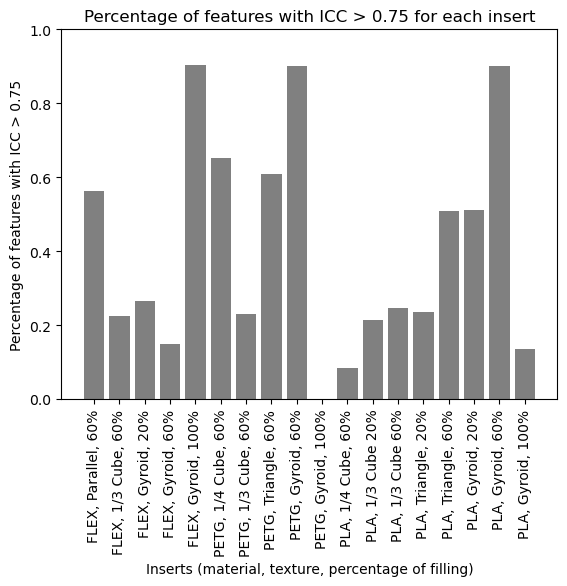

In [4]:
#per ogni colonna conta quanti elementi >= 3 ci sono e la percentuale su quanti elementi diversi da zero ci sono
for column in df_heat.columns[1:]:
    print(column, df_heat[df_heat[column] >= 3].shape[0], df_heat[df_heat[column] != 0].shape[0], df_heat[df_heat[column] >= 3].shape[0]/df_heat[df_heat[column] != 0].shape[0])

# print the inserts names
print(df_heat.columns[1:])

df_heat = df_heat[['Features', 'Cyl0', 'Cyl1', 'Cyl2', 'Cyl3', 'Rect14', 'Rect0', 'Rect1', 'Rect2', 'Rect3', 'Rect4',  'Rect5',  'Rect6',  'Rect7', 'Rect8',  'Rect9',  'Rect10',  'Rect11',  'Rect12',  'Rect13']]

print(df_heat.columns[1:])
#Fai un istogramma della percentuale di feature con ICC >= 3 per ogni insert
    
#crere un array di labels per l'asse x
x = np.array(['FLEX, Parallel, 60%', 'FLEX, 1/3 Cube, 60%', 'FLEX, Gyroid, 20%', 'FLEX, Gyroid, 60%', 'FLEX, Gyroid, 100%', 'PETG, 1/4 Cube, 60%', 'PETG, 1/3 Cube, 60%', 'PETG, Triangle, 60%', 'PETG, Gyroid, 60%', 'PETG, Gyroid, 100%', 'PLA, 1/4 Cube, 60%', 'PLA, 1/4 Cube, 60%', 'PLA, 1/3 Cube 20%', 'PLA, 1/3 Cube 60%', 'PLA, Triangle, 20%', 'PLA, Triangle, 60%', 'PLA, Gyroid, 20%', 'PLA, Gyroid, 60%', 'PLA, Gyroid, 100%'])
fig, ax = plt.subplots()
ax.bar(x, [df_heat[df_heat[column] >= 3].shape[0]/df_heat[df_heat[column] != 0].shape[0] for column in df_heat.columns[1:]], color='gray')
#metti le etichette degli inserti inclinate
plt.xticks(rotation=90)
ax.set_xlabel('Inserts (material, texture, percentage of filling)')
ax.set_ylabel('Percentage of features with ICC > 0.75')
ax.set_title('Percentage of features with ICC > 0.75 for each insert')
#y limit
plt.ylim(0, 1)
plt.show()


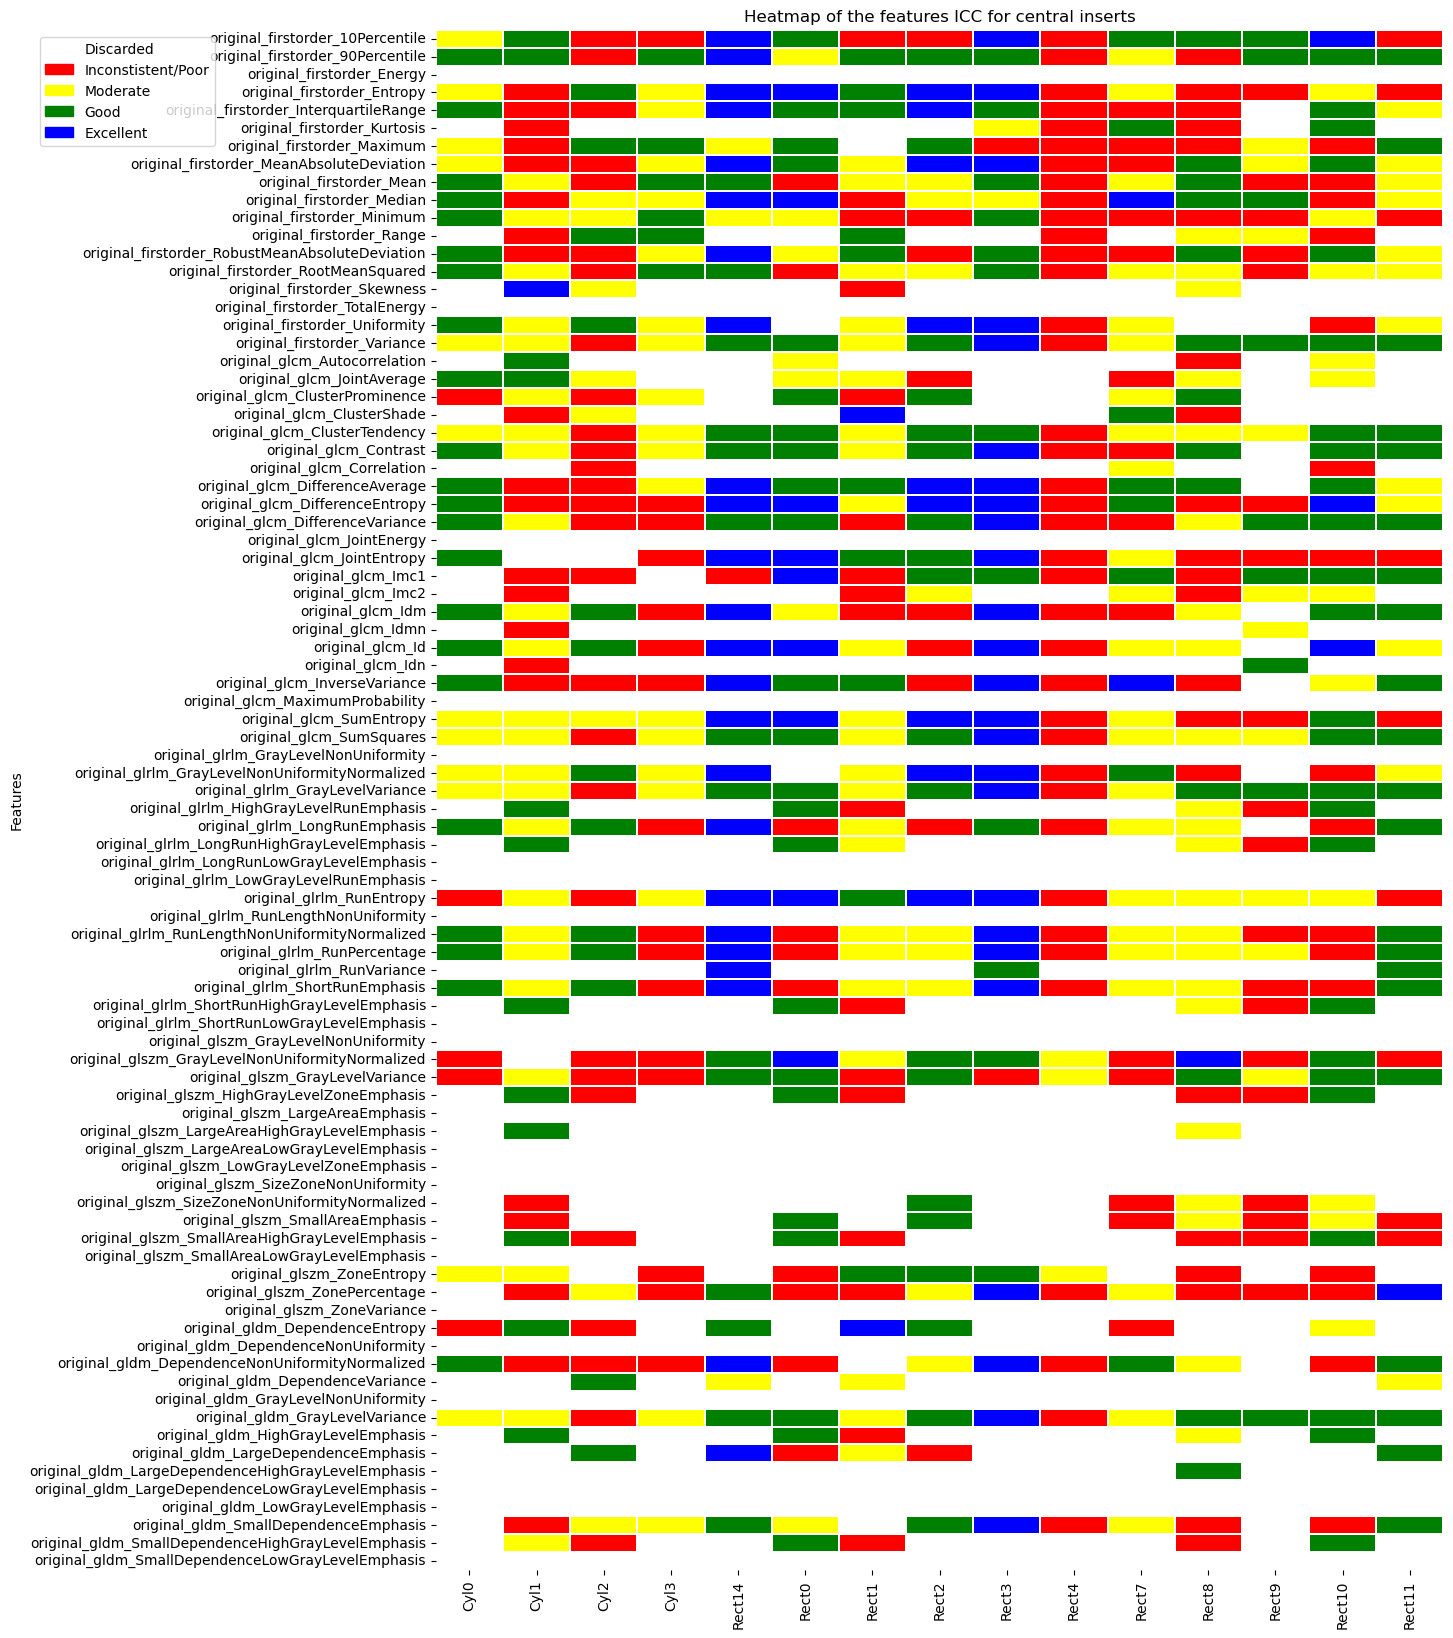

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect14,Rect0,Rect1,Rect2,Rect3,Rect4,Rect7,Rect8,Rect9,Rect10,Rect11
0,original_firstorder_10Percentile,2,3,1,1,4,3,1,1,4,1,3,3,3,4,1
1,original_firstorder_90Percentile,3,3,1,3,4,2,3,3,3,1,2,1,3,3,3
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,4,3,4,4,1,2,1,1,2,1
4,original_firstorder_InterquartileRange,3,1,1,2,4,3,3,4,3,1,1,1,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,3,2,0,3,4,1,2,1,0,1,3
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,0,3,1,0,0,0,0,1,0,3,0


In [5]:
#Change the order of the columns
df_heat = df_heat[['Features', 'Cyl0', 'Cyl1', 'Cyl2', 'Cyl3', 'Rect14', 'Rect0', 'Rect1', 'Rect2', 'Rect3', 'Rect4', 'Rect7', 'Rect8',  'Rect9',  'Rect10',  'Rect11']]

# Imposta 'Features' come indice del DataFrame
df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat_index
# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "yellow", "green", "blue"])

# Imposta le dimensioni della figura
plt.figure(figsize=(13, 20))

# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)

# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor')
yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good')
blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, yellow_patch, green_patch, blue_patch], bbox_to_anchor=(-0.4, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC for central inserts')


# Mostra il grafico
plt.show()

df_heat

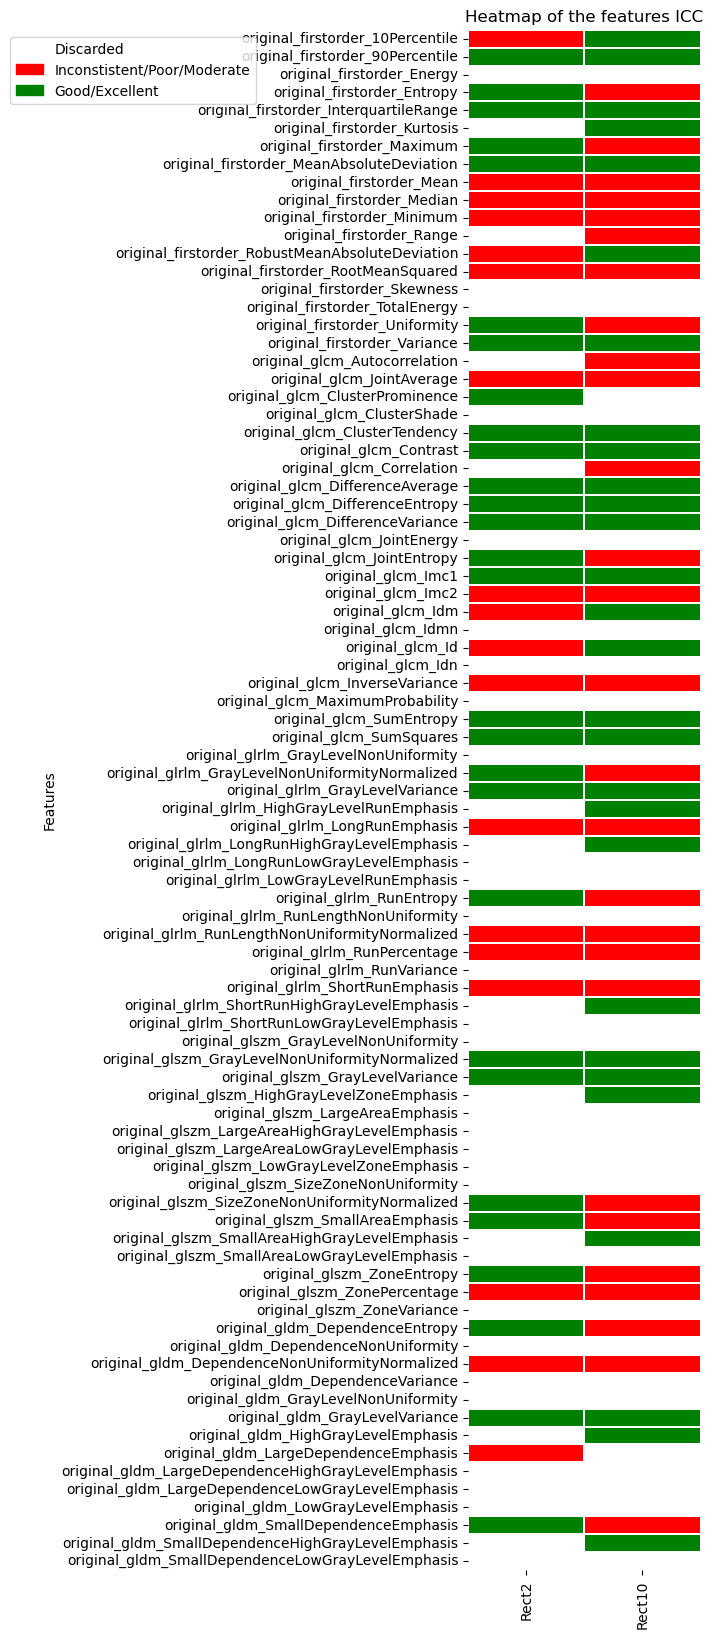

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect14,Rect0,Rect1,Rect2,Rect3,Rect4,Rect7,Rect8,Rect9,Rect10,Rect11
0,original_firstorder_10Percentile,2,3,1,1,4,3,1,1,4,1,3,3,3,4,1
1,original_firstorder_90Percentile,3,3,1,3,4,2,3,3,3,1,2,1,3,3,3
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,4,3,4,4,1,2,1,1,2,1
4,original_firstorder_InterquartileRange,3,1,1,2,4,3,3,4,3,1,1,1,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,3,2,0,3,4,1,2,1,0,1,3
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,0,3,1,0,0,0,0,1,0,3,0


In [6]:
#Change the order of the columns
#df_heat_3_10 = df_heat_index[['Cyl1', 'Rect3', 'Rect10']]
df_heat_3_10 = df_heat_index[[ 'Rect2', 'Rect10']]


# Imposta 'Features' come indice del DataFrame
#df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data_3_10 = df_heat_3_10

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "red", "green", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(3, 20))


# Crea la heatmap
sns.heatmap(heatmap_data_3_10, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)


# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor/Moderate')
#yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good/Excellent')
#blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, green_patch], bbox_to_anchor=(-2, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC')


# Mostra il grafico
plt.show()

df_heat

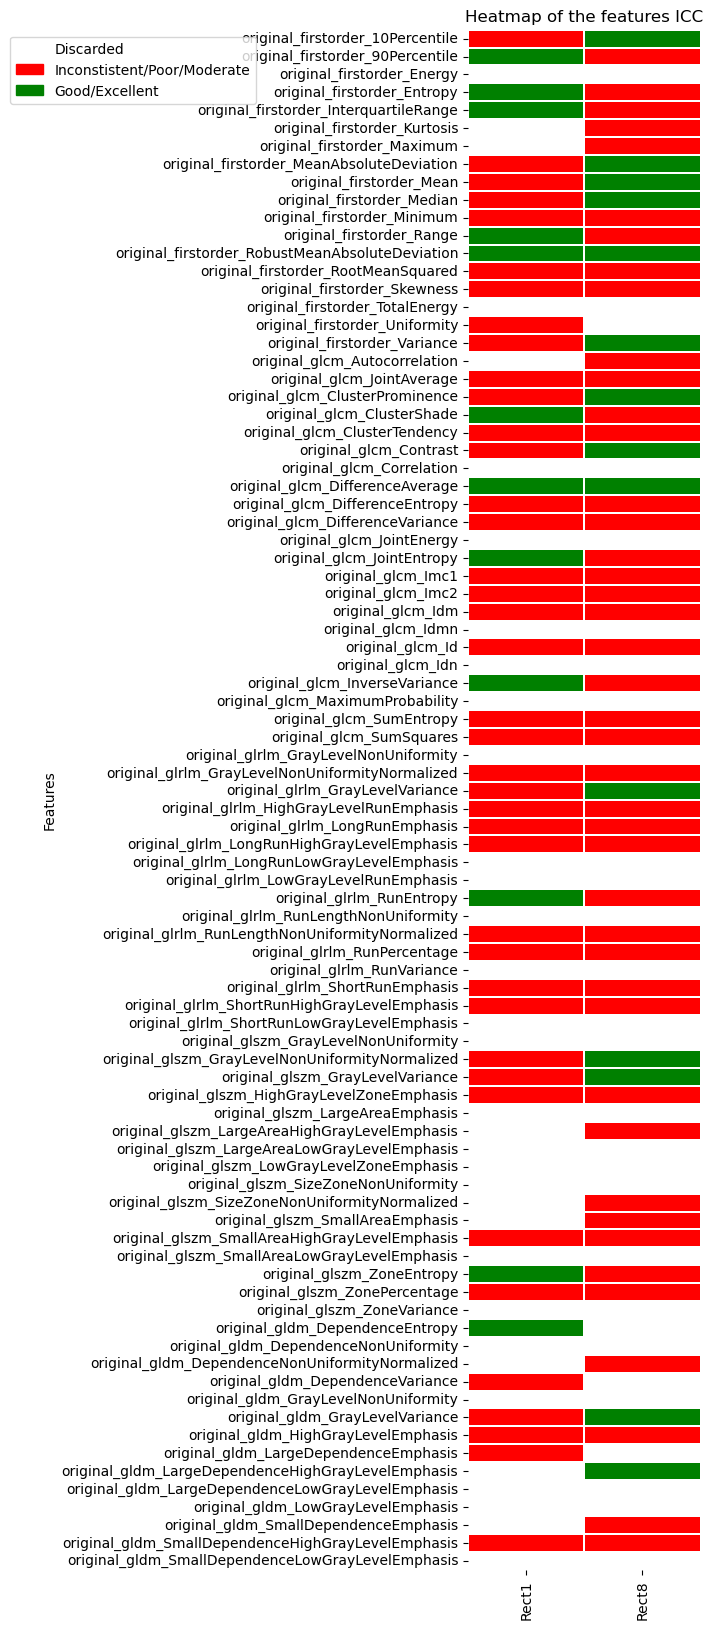

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect14,Rect0,Rect1,Rect2,Rect3,Rect4,Rect7,Rect8,Rect9,Rect10,Rect11
0,original_firstorder_10Percentile,2,3,1,1,4,3,1,1,4,1,3,3,3,4,1
1,original_firstorder_90Percentile,3,3,1,3,4,2,3,3,3,1,2,1,3,3,3
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,4,3,4,4,1,2,1,1,2,1
4,original_firstorder_InterquartileRange,3,1,1,2,4,3,3,4,3,1,1,1,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,3,2,0,3,4,1,2,1,0,1,3
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,0,3,1,0,0,0,0,1,0,3,0


In [7]:
#Change the order of the columns
#df_heat_3_10 = df_heat_index[['Cyl1', 'Rect3', 'Rect10']]
df_heat_3_10 = df_heat_index[[ 'Rect1', 'Rect8']]


# Imposta 'Features' come indice del DataFrame
#df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data_3_10 = df_heat_3_10

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "red", "green", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(3, 20))


# Crea la heatmap
sns.heatmap(heatmap_data_3_10, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)


# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor/Moderate')
#yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good/Excellent')
#blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, green_patch], bbox_to_anchor=(-2, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC')


# Mostra il grafico
plt.show()

df_heat

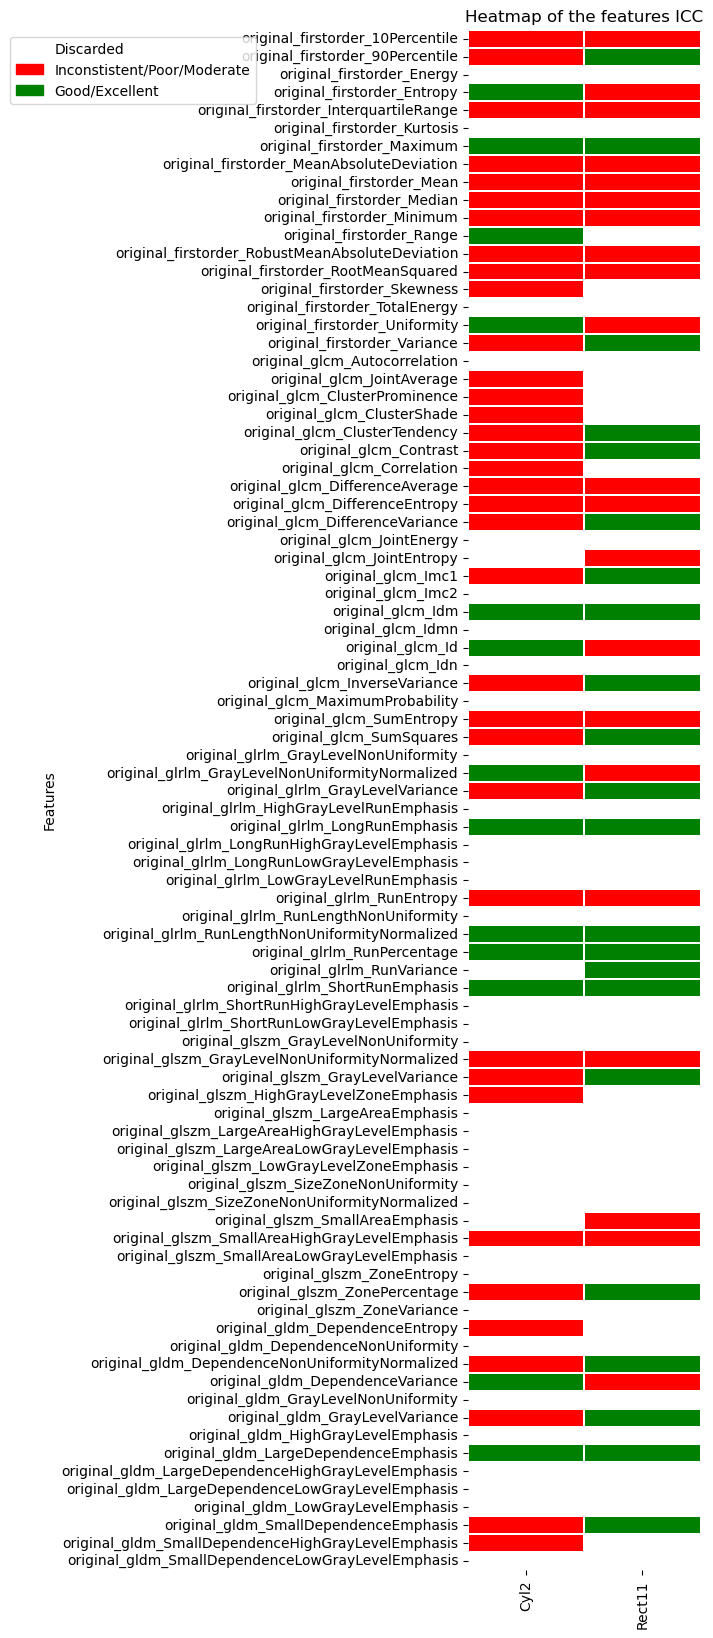

,Features,Cyl0,Cyl1,Cyl2,Cyl3,Rect14,Rect0,Rect1,Rect2,Rect3,Rect4,Rect7,Rect8,Rect9,Rect10,Rect11
0,original_firstorder_10Percentile,2,3,1,1,4,3,1,1,4,1,3,3,3,4,1
1,original_firstorder_90Percentile,3,3,1,3,4,2,3,3,3,1,2,1,3,3,3
2,original_firstorder_Energy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,original_firstorder_Entropy,2,1,3,2,4,4,3,4,4,1,2,1,1,2,1
4,original_firstorder_InterquartileRange,3,1,1,2,4,3,3,4,3,1,1,1,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,original_gldm_LowGrayLevelEmphasis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
83,original_gldm_SmallDependenceEmphasis,0,1,2,2,3,2,0,3,4,1,2,1,0,1,3
84,original_gldm_SmallDependenceHighGrayLevelEmph...,0,2,1,0,0,3,1,0,0,0,0,1,0,3,0


In [8]:
#Change the order of the columns
#df_heat_3_10 = df_heat_index[['Cyl1', 'Rect3', 'Rect10']]
df_heat_3_10 = df_heat_index[[ 'Cyl2', 'Rect11']]


# Imposta 'Features' come indice del DataFrame
#df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data_3_10 = df_heat_3_10

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "red", "green", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(3, 20))


# Crea la heatmap
sns.heatmap(heatmap_data_3_10, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)


# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor/Moderate')
#yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good/Excellent')
#blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, green_patch], bbox_to_anchor=(-2, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC')


# Mostra il grafico
plt.show()

df_heat

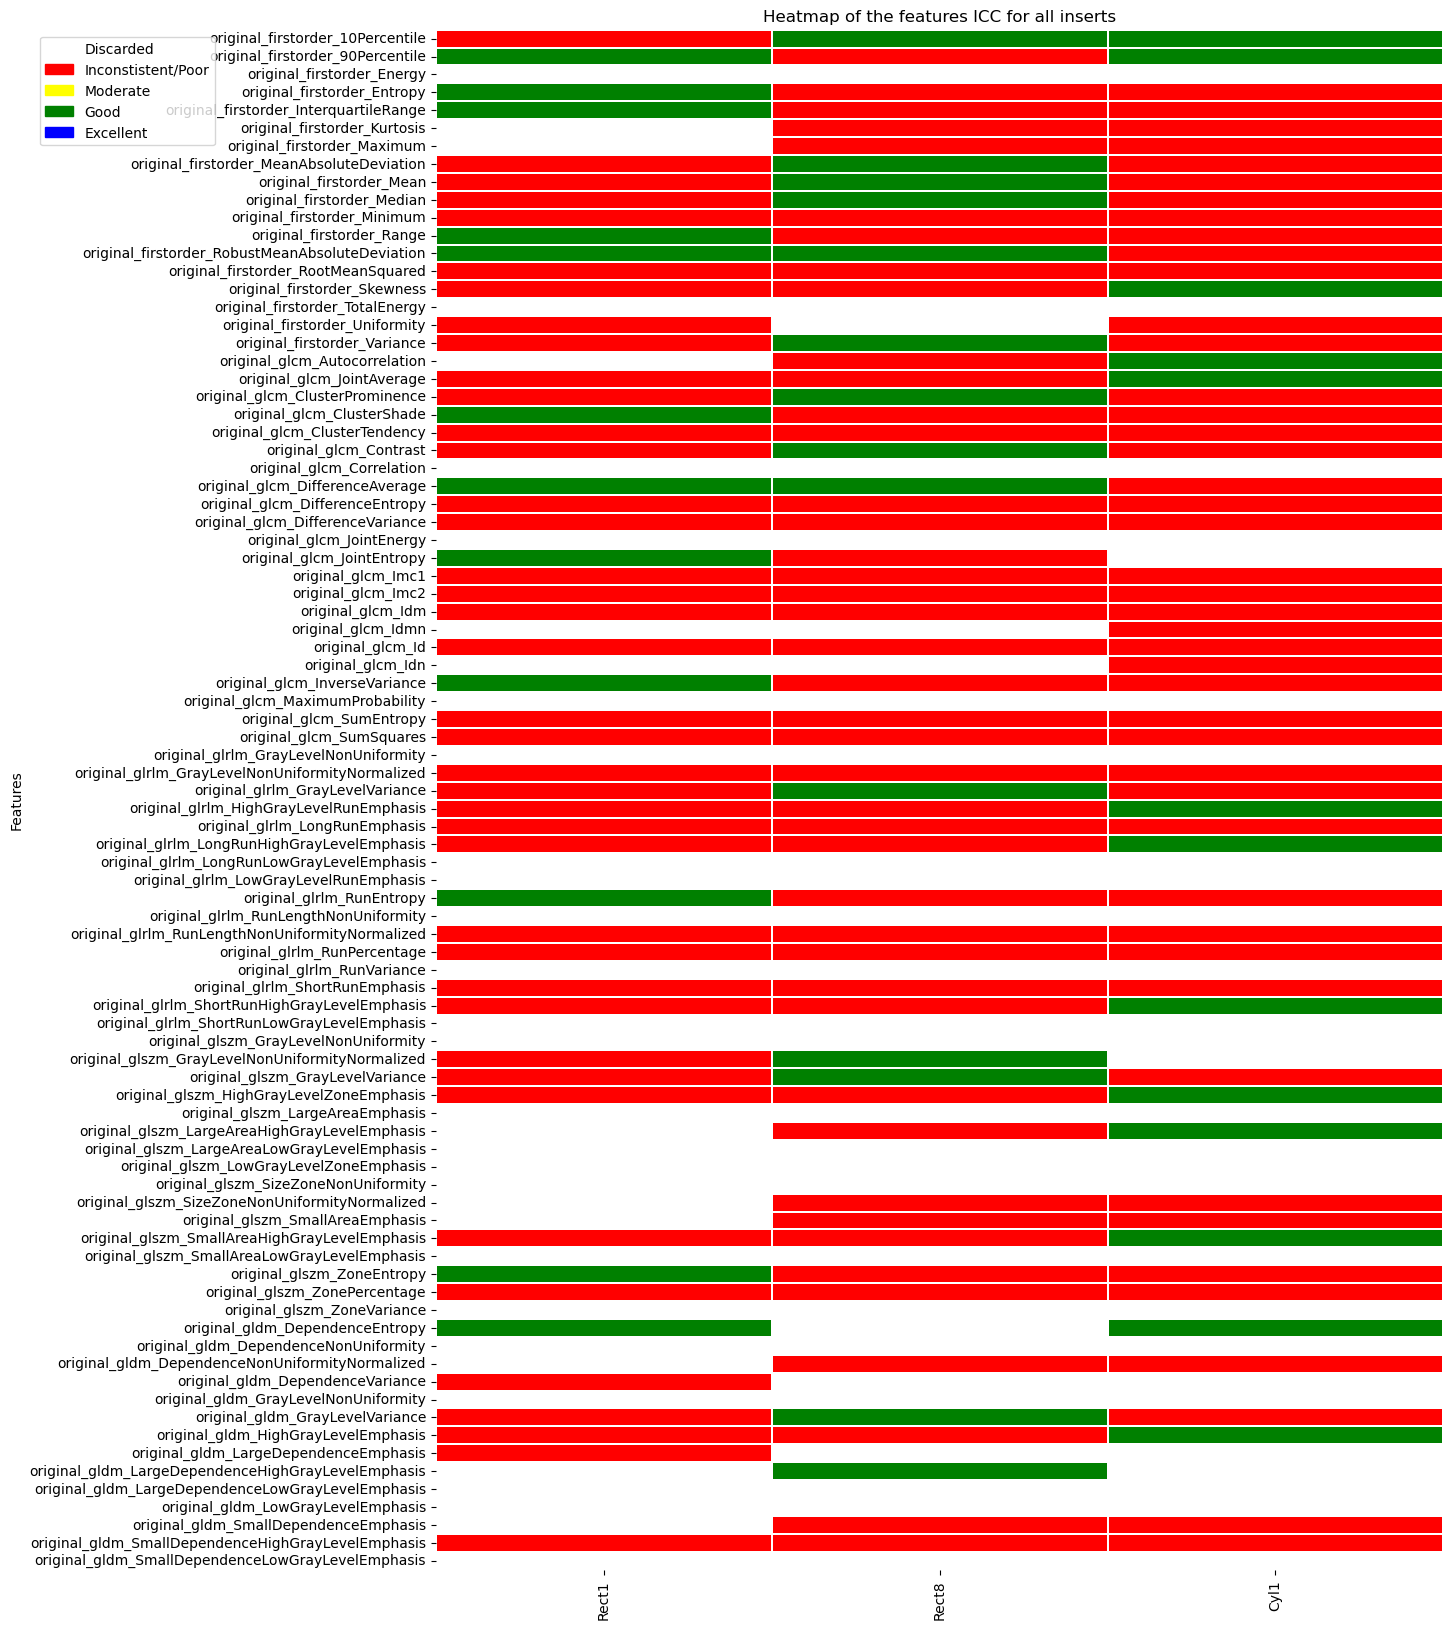

,Rect1,Rect8,Cyl1
Features,,,
original_firstorder_10Percentile,1,3,3
original_firstorder_90Percentile,3,1,3
original_firstorder_Energy,0,0,0
original_firstorder_Entropy,3,1,1
original_firstorder_InterquartileRange,3,1,1
...,...,...,...
original_gldm_LargeDependenceLowGrayLevelEmphasis,0,0,0
original_gldm_LowGrayLevelEmphasis,0,0,0
original_gldm_SmallDependenceEmphasis,0,1,1


In [9]:
#Change the order of the columns
df_heat = df_heat_index[['Rect1', 'Rect8', 'Cyl1']]


# Imposta 'Features' come indice del DataFrame
#df_heat_index = df_heat.set_index('Features')

# Seleziona solo le colonne che vuoi includere nella heatmap
heatmap_data = df_heat

# Crea una mappa di colori con il rosso per 0 e il verde per 1
cmap = sns.color_palette(["white", "red", "red", "green", "green"])

# Imposta le dimensioni della figura
plt.figure(figsize=(13, 20))


# Crea la heatmap
sns.heatmap(heatmap_data, cmap=cmap, cbar=False, yticklabels=True, linewidths=0.01)


# Crea una legenda personalizzata
black_patch = mpatches.Patch(color='white', label='Discarded')
red_patch = mpatches.Patch(color='red', label='Inconstistent/Poor')
yellow_patch = mpatches.Patch(color='yellow', label='Moderate')
green_patch = mpatches.Patch(color='green', label='Good')
blue_patch = mpatches.Patch(color='blue', label='Excellent')
plt.legend(handles=[black_patch, red_patch, yellow_patch, green_patch, blue_patch], bbox_to_anchor=(-0.4, 1), loc='upper left')


# Imposta le etichette dell'asse x per essere scritte verticalmente
plt.xticks(rotation=90)

#set the title
plt.title('Heatmap of the features ICC for all inserts')


# Mostra il grafico
plt.show()

df_heat